---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 13. Прилади із зарядовим зв'язком, терморезистори та варістори</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Прилади із зарядовим зв'язком: МДН-конденсатор, потенціальні ями, перенесення заряду</li>
  <li>ПЗЗ-фотоприймачі: лінійки й матриці, ефективність перенесення, ПЗЗ і КМОН</li>
  <li>Терморезистори з від'ємним (NTC) і додатним (PTC) ТКО, саморозігрів</li>
  <li>Варістори: структура ZnO-кераміки, ВАХ, захист від перенапруг</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 13 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Прилади із зарядовим зв'язком (ПЗЗ)](#ccd)
    * [🔬 Інтерактивно: трифазне перенесення зарядових пакетів](#ccd-transfer)
    * [🔬 Інтерактивно: ефективність перенесення і «розмиття» зображення](#ccd-cte)
* [Терморезистори](#thermistor)
    * [🔬 Інтерактивно: ВАХ терморезистора з саморозігрівом](#ntc-iv)
    * [⚙️ PySpice: обмеження пускового струму NTC-терморезистором](#spice-inrush)
* [Варістори](#varistor)
    * [⚙️ PySpice: захист від імпульсної перенапруги](#spice-surge)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

def ntc_R(T_C, R25=10e3, B=3950):
    """Опір NTC-терморезистора: R = R25·exp(B(1/T − 1/T25))"""
    return R25*np.exp(B*(1/(np.asarray(T_C) + 273.15) - 1/298.15))

---

# Прилади із зарядовим зв'язком (ПЗЗ) <a class="anchor" id="ccd"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Пояснювати утворення потенціальної ями під затвором МДН-конденсатора в режимі глибокого збіднення
> - Описувати трифазне перенесення зарядових пакетів і вузли введення та виведення заряду ПЗЗ
> - Оцінювати вплив ефективності перенесення на якість зображення, порівнювати ПЗЗ і КМОН-сенсори
> - Пояснювати принцип дії, характеристики й застосування NTC- і PTC-терморезисторів, ефект саморозігріву
> - Пояснювати фізику варисторного ефекту в ZnO-кераміці та вибирати варістор для захисту від перенапруг

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **ПЗЗ (CCD)** | Масив щільно розташованих МДН-конденсаторів, між якими зарядові пакети переміщуються зміною напруг на затворах |
| **Потенціальна яма** | Область під затвором з додатною (для p-підкладки) напругою, де накопичуються електрони |
| **Ефективність перенесення $\eta$ (CTE)** | Частка заряду, перенесена за один такт; після $N$ тактів залишається $\eta^N$ |
| **Терморезистор** | Резистор з сильною залежністю опору від температури: NTC — від'ємний ТКО, PTC (позистор) — додатний |
| **Коефіцієнт B** | Параметр NTC: $R(T) = R_{25}\exp[B(1/T - 1/T_{25})]$, 3000–5000 К |
| **Варістор** | Резистор з різко нелінійною симетричною ВАХ $I = kU^{\alpha}$, $\alpha$ = 20–60 для ZnO |

**Прилад із зарядовим зв'язком** (ПЗЗ, CCD — charge-coupled device; У. Бойл і Дж. Сміт, 1969; Нобелівська премія 2009) — ланцюжок **МДН-конденсаторів** на спільній напівпровідниковій підкладці з дуже малими (1–3 мкм) проміжками між затворами. Інформація зберігається не у вигляді напруги чи струму, а у вигляді **зарядових пакетів** неосновних носіїв, які переміщуються від затвора до затвора.

**Потенціальна яма.** Якщо на затвор МДН-конденсатора на p-кремнії швидко подати додатну напругу, більшу за порогову, інверсійний шар не встигає утворитися (теплова генерація триває секунди), і під затвором виникає **глибоке збіднення** — область з високим поверхневим потенціалом. Для електронів це **потенціальна яма**: глибина пропорційна напрузі на затворі, а ємність ями (максимальний заряд пакета, «повна ємність пікселя») — 10⁴–10⁶ електронів. Заряд у ямі зберігається, доки його не «заповнить» темновий струм — від мілісекунд до годин (при охолодженні).

**Перенесення заряду.** Якщо на сусідній затвор подати вищу напругу, його яма стає глибшою і ями зливаються — заряд «перетікає» в глибшу яму (дрейф у крайовому полі, самоіндуковане поле й дифузія). Потім напругу на першому затворі знімають, і весь пакет опиняється під другим. У **трифазному** ПЗЗ кожен елемент (піксель) має три затвори, з'єднані через два з шинами φ1, φ2, φ3; за повний цикл тактових імпульсів усі пакети зсуваються на один піксель — ПЗЗ працює як **аналоговий зсувний регістр**. Застосовують також дво- і чотирифазні ПЗЗ, ПЗЗ з **прихованим (об'ємним) каналом** — заряд переноситься в глибині n-шару, далеко від поверхневих пасток, що підвищує ефективність перенесення.

**Введення заряду:** електрично — через вхідний діод і вхідний затвор (лінії затримки, аналогова обробка сигналів), або **оптично** — фотогенерацією в ямах під час експозиції (фотоприймачі). **Виведення:** в кінці регістра пакет потрапляє на **плаваючу дифузійну область** малої ємності $C$ (кілька фФ); зміна її потенціалу $\Delta U = Q/C$ (1–50 мкВ на електрон) підсилюється вбудованим витоковим повторювачем, після чого вузол скидається транзистором скидання. Подвійна корельована вибірка усуває шум скидання.

**Фотоприймальні ПЗЗ:** **лінійки** (сканери, спектрометри, датчики положення) і **матриці**: з **повнокадровим перенесенням** (максимальна площа фотоприймача, потрібен механічний затвор — астрономія), з **кадровим перенесенням** (зона накопичення + закрита зона пам'яті), з **міжрядковим перенесенням** (кожен стовпчик фотодіодів має поруч закритий регістр — відеокамери, «електронний затвор»). Кольорові сенсори мають мозаїчний фільтр Байєра.

**ПЗЗ і КМОН-сенсори.** КМОН-сенсор (активний піксель: фотодіод + 3–4 транзистори в кожному пікселі) читає кожен піксель окремо, інтегрується з АЦП і обробкою на одному кристалі, споживає менше енергії й дешевший — тому витіснив ПЗЗ зі смартфонів і камер. ПЗЗ зберігають позиції там, де потрібні мінімальний шум, висока однорідність і квантова ефективність: астрономія, наукова спектроскопія, рентгенівська та медична візуалізація, деякі промислові камери.

### 🔬 Інтерактивно: трифазне перенесення зарядових пакетів <a class="anchor" id="ccd-transfer"></a>

Три пікселі по три затвори (φ1, φ2, φ3). На кожному такті змінюються напруги фаз: «високий» рівень (10 В) утворює глибоку яму, «низький» (2 В) — бар'єр. Зарядові пакети різної величини (різна освітленість пікселів) перетікають у глибші ями; за 6 тактів (повний цикл) кожен пакет зсувається рівно на один піксель праворуч, до вихідного вузла.

In [2]:
PHASES = [(1, 0, 0), (1, 1, 0), (0, 1, 0), (0, 1, 1), (0, 0, 1), (1, 0, 1), (1, 0, 0)]   # такти: φ1, φ2, φ3 (1 — високий рівень)
N_PIX = 4; N_GATE = 3*N_PIX
Q0 = [0.0, 0.85, 0.35, 0.6]          # початкові заряди під затворами φ1 пікселів (освітленість)

def ccd_state(step):
    """Положення пакетів: кожен пакет займає ями з високим рівнем у межах свого «блоку» затворів."""
    shift, sub = divmod(step, 6)
    ph = PHASES[sub]
    occupancy = np.zeros(N_GATE)
    for p, q in enumerate(Q0):
        g0 = 3*p + 3*shift                       # затвор φ1 пакета p після повних циклів
        if sub == 0:   gates = [g0]
        elif sub == 1: gates = [g0, g0 + 1]
        elif sub == 2: gates = [g0 + 1]
        elif sub == 3: gates = [g0 + 1, g0 + 2]
        elif sub == 4: gates = [g0 + 2]
        else:          gates = [g0 + 2, g0 + 3]
        gates = [g for g in gates if g < N_GATE]
        for g in gates:
            occupancy[g] += q/len(gates) if gates else 0
    levels = np.array([10.0 if ph[g % 3] else 2.0 for g in range(N_GATE)])
    return levels, occupancy, ph

def ccd_transfer(step=0):
    levels, occ, ph = ccd_state(step)
    fig, axes = plt.subplots(2, 1, figsize=(13, 6), gridspec_kw={'height_ratios': [1, 2.2]}, sharex=True)
    ax = axes[0]
    for g in range(N_GATE):
        col = ['#dc2626', '#16a34a', '#2563eb'][g % 3]
        ax.add_patch(patches.Rectangle((g + 0.05, 0), 0.9, 1, facecolor=col if levels[g] > 5 else 'white', edgecolor=col, lw=2))
        ax.text(g + 0.5, 0.5, f'φ{g % 3 + 1}', ha='center', va='center', fontsize=10, color='k')
    for p in range(N_PIX):
        ax.text(3*p + 1.5, 1.25, f'піксель {p + 1}', ha='center', fontsize=10)
    ax.set_ylim(0, 1.6); ax.set_yticks([]); ax.set_title(f'Такт {step}: φ1 = {"В" if ph[0] else "Н"}, φ2 = {"В" if ph[1] else "Н"}, φ3 = {"В" if ph[2] else "Н"}  (В — 10 В, Н — 2 В)')
    ax = axes[1]
    x = np.linspace(0, N_GATE, 1200)
    phi_s = np.interp(x, np.arange(N_GATE) + 0.5, levels)
    from scipy.ndimage import gaussian_filter1d
    phi_s = gaussian_filter1d(np.array([levels[min(int(xx), N_GATE - 1)] for xx in x]), 12)
    ax.plot(x, -phi_s, color='k', lw=2, label='дно зони провідності (потенціальна енергія електрона)')
    for g in range(N_GATE):
        if occ[g] > 0:
            depth = levels[g]
            ax.fill_between([g + 0.12, g + 0.88], -depth, -depth + 7*occ[g], color='#2563eb', alpha=0.75)
    ax.annotate('вихідний\nвузол →', xy=(N_GATE, -6), fontsize=10, ha='right')
    ax.set_ylim(-11, 0.5); ax.set_xlim(0, N_GATE); ax.set_xticks([]); ax.set_ylabel('$-\\psi_s$, В (вниз — глибша яма)')
    ax.legend(fontsize=9, loc='lower left'); ax.set_title('Потенціальні ями і зарядові пакети (синім)')
    plt.tight_layout(); plt.show()

interact(ccd_transfer, step=widgets.IntSlider(min=0, max=6, step=1, value=0, description='такт'));

interactive(children=(IntSlider(value=0, description='такт', max=6), Output()), _dom_classes=('widget-interact…

### 🔬 Інтерактивно: ефективність перенесення і «розмиття» зображення <a class="anchor" id="ccd-cte"></a>

За кожне перенесення частка заряду $1-\eta$ залишається позаду (пастки на межі Si–SiO₂, неповне перетікання). Після $N$ перенесень у пакеті залишається $\eta^N$ початкового заряду, а «відсталий» заряд утворює **хвіст** за яскравою точкою. Матриця 4096 × 4096 у трифазному ПЗЗ вимагає до $3\cdot 8192$ перенесень для найвіддаленішого пікселя, тому потрібна $\eta \ge 0{,}99999$. Розподіл заряду після $N$ тактів — біноміальний: частка, що відстала на $k$ тактів, дорівнює $C_N^k(1-\eta)^k\eta^{N-k}$.

In [3]:
from scipy.stats import binom

def cte_demo(cte_exp=4.0, N_pix=1000):
    eta = 1 - 10**(-cte_exp)
    N = 3*N_pix                                           # трифазний ПЗЗ: 3 перенесення на піксель
    lag = np.arange(0, 60)
    frac = binom.pmf(lag, N, 1 - eta)                     # частка заряду, що відстала на k тактів
    trail = np.add.reduceat(frac, np.arange(0, 60, 3))    # згрупувати по пікселях (3 такти)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
    axes[0].bar(np.arange(len(trail)), trail, color='#2563eb')
    axes[0].set_xlabel('відставання, пікселів'); axes[0].set_ylabel('частка заряду пакета')
    axes[0].set_title(f'Профіль яскравої точки після {N} перенесень, η = 1 − 10$^{{-{cte_exp:g}}}$')
    axes[0].set_ylim(0, 1.05)
    Ns = np.arange(0, 3*4096 + 1, 64)
    for e, col in [(2, '#dc2626'), (3, '#f59e0b'), (4, '#16a34a'), (5, '#2563eb'), (6, '#7c3aed')]:
        axes[1].plot(Ns, (1 - 10**(-e))**Ns, color=col, label=f'η = 1 − 10$^{{-{e}}}$')
    axes[1].axvline(N, color='gray', ls=':')
    axes[1].set_xlabel('кількість перенесень N'); axes[1].set_ylabel('$\\eta^N$'); axes[1].set_ylim(0, 1.02)
    axes[1].set_title('Частка заряду, що дійшла до виходу'); axes[1].legend(fontsize=9)
    plt.tight_layout(); plt.show()
    print(f'η^N = {eta**N:.4f}: до виходу доходить {eta**N*100:.2f} % заряду пакета, решта розмазана в «хвіст»')

interact(cte_demo,
         cte_exp=widgets.FloatSlider(min=2, max=6, step=0.5, value=4, description='−lg(1−η)', continuous_update=False),
         N_pix=widgets.SelectionSlider(options=[100, 500, 1000, 2000, 4096], value=1000, description='пікселів', continuous_update=False));

interactive(children=(FloatSlider(value=4.0, continuous_update=False, description='−lg(1−η)', max=6.0, min=2.0…

---

# Терморезистори <a class="anchor" id="thermistor"></a>

**Терморезистор** — напівпровідниковий резистор, опір якого сильно залежить від температури. Розрізняють **термістори** з від'ємним температурним коефіцієнтом опору (**NTC**) і **позистори** з додатним (**PTC**).

**NTC-терморезистори.** **Конструкція:** спечена полікристалічна кераміка з оксидів перехідних металів (Mn, Ni, Co, Cu, Fe) зі структурою шпінелі; форми — диски й шайби з виводами, бусинки в склі (швидкі, стабільні, до 300 °C), SMD-чипи 0402–1206, герметичні зонди. Для кріогенних температур — монокристалічні Ge, Si. **Принцип дії:** концентрація носіїв (стрибкова провідність між іонами різної валентності) зростає з температурою експоненційно, як у напівпровідника з енергією активації $E_a$:

$$R(T) = R_{25}\,\exp\left[B\left(\frac{1}{T}-\frac{1}{T_{25}}\right)\right], \qquad \alpha_R = \frac{1}{R}\frac{dR}{dT} = -\frac{B}{T^2},$$

де $B = E_a/k$ = 3000–5000 К; при 25 °C $\alpha_R$ ≈ −3…−5 %/°C — у 10 разів більше за модуль ТКО платинового термометра. Для точних розрахунків застосовують рівняння Стейнхарта–Харта $1/T = a + b\ln R + c\ln^3 R$.

**PTC-терморезистори (позистори).** Кераміка **титанату барію** BaTiO₃, легована La, Sb або Nb до напівпровідникового стану. Нижче точки Кюрі $T_C$ (60–130 °C — задається добавками Sr, Pb) кераміка — сегнетоелектрик, спонтанна поляризація компенсує поверхневі заряди на межах зерен, бар'єри низькі. Вище $T_C$ діелектрична проникність різко падає, бар'єри на межах зерен зростають, і опір збільшується на **3–6 порядків** у вузькому інтервалі температур. Існують також **кремнієві** PTC-датчики (KTY81/84, майже лінійні) і **полімерні** PPTC (самовідновлювані запобіжники — провідна сажа в полімері, що розширюється при нагріванні).

**Саморозігрів.** Струм нагріває терморезистор: в усталеному режимі $UI = \delta\,(T - T_{навк})$, де $\delta$ — **коефіцієнт розсіювання** (мВт/°C), а теплова постійна часу $\tau = C_{тепл}/\delta$ — від 0,1 с (бусинки) до хвилин. Для вимірювань струм обмежують так, щоб похибка саморозігріву $P/\delta$ була малою; для силових застосувань, навпаки, саморозігрів — робочий ефект.

**Основні параметри:** номінальний опір $R_{25}$ і допуск; B-константа ($B_{25/85}$); ТКО; коефіцієнт розсіювання і теплова постійна часу; максимальна потужність, діапазон температур; для PTC — температура перемикання $T_C$, кратність зміни опору, струми неспрацювання / спрацювання.

**Застосування.** NTC: вимірювання і регулювання температури (побутова техніка, автомобіль, акумулятори, медичні термометри), **температурна компенсація** (кварцових генераторів, РК-дисплеїв, транзисторних каскадів), **обмеження пускового струму** імпульсних блоків живлення і двигунів. PTC: **самовідновлювані запобіжники** і захист від перевантаження (трансформатори, двигуни, акумуляторні батареї), саморегульовані нагрівачі (обігрівачі, фени), пускові реле однофазних двигунів компресорів холодильників, датчики перегріву обмоток, колишнє розмагнічування кінескопів.

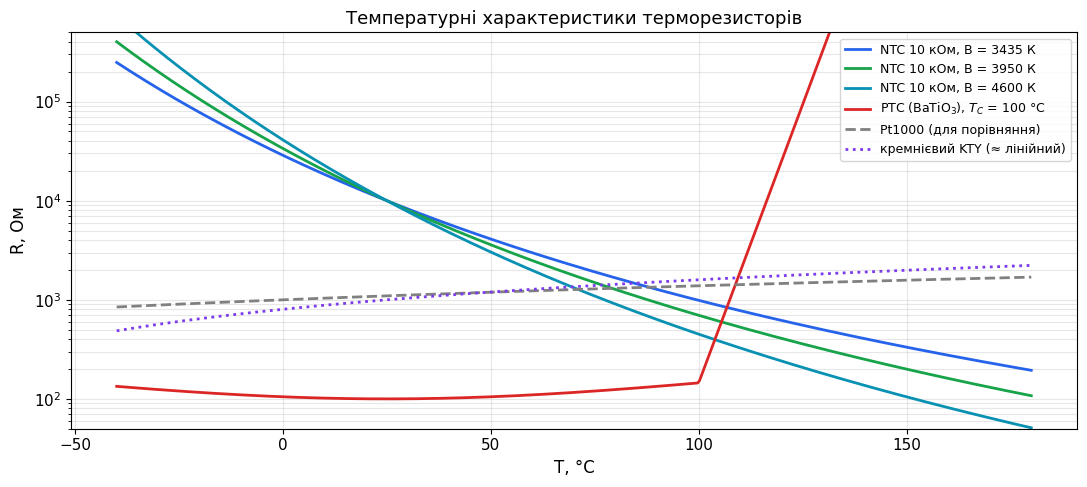

NTC B = 3435: R(0 °C) = 28.7 кОм, R(100 °C) = 0.99 кОм; ТКО при 25 °C = -3.86 %/°C
NTC B = 3950: R(0 °C) = 33.6 кОм, R(100 °C) = 0.70 кОм; ТКО при 25 °C = -4.44 %/°C


In [4]:
T = np.linspace(-40, 180, 500)
fig, ax = plt.subplots(figsize=(11, 5))
for B, col in [(3435, '#2563eb'), (3950, '#16a34a'), (4600, '#0891b2')]:
    ax.semilogy(T, ntc_R(T, 10e3, B), color=col, label=f'NTC 10 кОм, B = {B} К')
# PTC: спрощена модель BaTiO3 — мінімум біля 25 °C, різке зростання вище точки Кюрі
Tc = 100
R_ptc = 100*(1 + 0.004*(T - 25)**2/50)*np.where(T < Tc, 1, 1)*np.exp(np.clip((T - Tc)/4.0, 0, 9))
ax.semilogy(T, R_ptc, color='#dc2626', label=f'PTC (BaTiO$_3$), $T_C$ = {Tc} °C')
ax.semilogy(T, 1000*(1 + 3.85e-3*T), color='gray', ls='--', label='Pt1000 (для порівняння)')
ax.semilogy(T, 1000*(1 + 7.9e-3*(T - 25)), color='#7c3aed', ls=':', label='кремнієвий KTY (≈ лінійний)')
ax.set_xlabel('T, °C'); ax.set_ylabel('R, Ом'); ax.set_ylim(50, 5e5)
ax.set_title('Температурні характеристики терморезисторів'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()
for B in (3435, 3950):
    print(f'NTC B = {B}: R(0 °C) = {ntc_R(0, 10e3, B)/1e3:.1f} кОм, R(100 °C) = {ntc_R(100, 10e3, B)/1e3:.2f} кОм; ТКО при 25 °C = {-B/298.15**2*100:.2f} %/°C')

### 🔬 Інтерактивно: ВАХ терморезистора з саморозігрівом <a class="anchor" id="ntc-iv"></a>

Статична ВАХ NTC-терморезистора будується з умови теплового балансу $UI = \delta(T - T_{навк})$ і закону Ома $U = IR(T)$: для кожної температури $P = \delta(T - T_{навк})$, $I = \sqrt{P/R(T)}$, $U = \sqrt{PR(T)}$. На малих струмах саморозігрів неістотний — ВАХ лінійна (режим вимірювання). Далі напруга досягає **максимуму** $U_{max}$ і з подальшим зростанням струму **спадає** — ділянка від'ємного диференціального опору (режим обмежувача пускового струму, реле часу, стабілізатора).

In [5]:
def ntc_iv(delta_mW=5.0, R25_kOhm=10.0, T_amb=25):
    Ts = np.linspace(T_amb + 0.01, 250, 4000)
    P = delta_mW*1e-3*(Ts - T_amb); R = ntc_R(Ts, R25_kOhm*1e3, 3950)
    I, U = np.sqrt(P/R), np.sqrt(P*R)
    k = np.argmax(U)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].plot(I*1e3, U, color='#2563eb')
    axes[0].plot(I[k]*1e3, U[k], 'ro'); axes[0].annotate(f'$U_{{max}}$ = {U[k]:.1f} В при T = {Ts[k]:.0f} °C', (I[k]*1e3, U[k]),
                                                         xytext=(20, -10), textcoords='offset points')
    I_lin = np.linspace(0, I[k]*0.8, 10)
    axes[0].plot(I_lin*1e3, I_lin*ntc_R(T_amb, R25_kOhm*1e3, 3950), 'k:', label='без саморозігріву: U = I·R(T$_{навк}$)')
    axes[0].set_xlabel('I, мА'); axes[0].set_ylabel('U, В'); axes[0].legend(fontsize=9)
    axes[0].set_title(f'Статична ВАХ NTC: $R_{{25}}$ = {R25_kOhm} кОм, δ = {delta_mW} мВт/°C'); axes[0].set_xlim(0, min(I[-1], 8*I[k])*1e3)
    axes[1].semilogx(I*1e3, Ts, color='#dc2626')
    axes[1].set_xlabel('I, мА'); axes[1].set_ylabel('T терморезистора, °C'); axes[1].set_title('Температура саморозігріву')
    axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    I_meas = np.sqrt(delta_mW*1e-3*0.1/ntc_R(T_amb, R25_kOhm*1e3, 3950))
    print(f'Щоб похибка саморозігріву не перевищувала 0,1 °C, струм вимірювання ≤ {I_meas*1e6:.0f} мкА')

interact(ntc_iv,
         delta_mW=widgets.SelectionSlider(options=[1.0, 2.0, 5.0, 10.0, 20.0], value=5.0, description='δ, мВт/°C', continuous_update=False),
         R25_kOhm=widgets.SelectionSlider(options=[1.0, 4.7, 10.0, 47.0, 100.0], value=10.0, description='$R_{25}$, кОм', continuous_update=False),
         T_amb=widgets.IntSlider(min=-20, max=60, step=10, value=25, description='$T_{навк}$, °C', continuous_update=False));

interactive(children=(SelectionSlider(continuous_update=False, description='δ, мВт/°C', index=2, options=(1.0,…

### ⚙️ PySpice: обмеження пускового струму NTC-терморезистором <a class="anchor" id="spice-inrush"></a>

У момент ввімкнення блока живлення конденсатор фільтра (тут 470 мкФ) розряджений і заряджається від випрямленої мережевої напруги 325 В майже без обмеження — пусковий струм сягає сотень ампер і руйнує діоди та контакти. Послідовний **NTC-терморезистор** (типу SG-200, 10 Ом при 25 °C) у холодному стані обмежує цей кидок, а потім розігрівається власним струмом, і його опір падає до десятих часток ома — втрати в робочому режимі малі.

**Електротеплова модель в ngspice:** опір NTC — поведінкове джерело струму `B`, що залежить від напруги «теплового» вузла `th` (напруга в вольтах = температура в °C); потужність $i^2R$ — джерело струму в тепловому колі з тепловою ємністю $C_{тепл}$ і тепловим опором $R_{тепл}$ до навколишнього середовища — **електротеплова аналогія** (В ↔ °C, А ↔ Вт).

In [6]:
def inrush(limiter='NTC', R_load=200, C_uF=470):
    R25, B = 10.0, 3000
    c = Circuit('Inrush current limiter')
    c.PulseVoltageSource('s', 's', c.gnd, initial_value=0, pulsed_value=325, delay_time=1e-3, rise_time=10e-6,
                         fall_time=1e-6, pulse_width=1000, period=2000)        # ввімкнення в максимум напруги мережі
    if limiter == 'NTC':
        c.V('amb', 'amb', c.gnd, 25)
        R_expr = f'({R25}*exp({B}*(1/(v(th)+273.15)-1/298.15)))'
        c.B('ntc', 's', 'n', i=f'v(s,n)/{R_expr}')
        c.B('heat', c.gnd, 'th', i=f'v(s,n)*v(s,n)/{R_expr}')               # потужність у тепловий вузол
        c.R('th', 'th', 'amb', 30)                                         # тепловий опір, °C/Вт
        c.C('th', 'th', 'amb', 1.0)                                        # теплоємність диска Ø15 мм, Дж/°C (τ = 30 с)
    elif limiter == 'резистор 10 Ом':
        c.R('lim', 's', 'n', 10)
    else:
        c.R('lim', 's', 'n', 0.3)                                          # лише опір проводів і мережі
    c.C('f', 'n', c.gnd, C_uF*1e-6); c.R('n', 'n', c.gnd, R_load)
    def current(an):
        u_s, u_n = np.array(an['s']), np.array(an['n'])
        if limiter == 'NTC':
            return (u_s - u_n)/(R25*np.exp(B*(1/(np.array(an['th']) + 273.15) - 1/298.15)))
        return (u_s - u_n)/(10 if limiter.startswith('резистор') else 0.3)
    an0 = c.simulator().transient(step_time=5e-6, end_time=0.05, max_time=20e-6)     # пусковий процес — дрібний крок
    t0 = np.array(an0.time); i0 = current(an0)
    an = c.simulator().transient(step_time=10e-6, end_time=150.0, max_time=50e-3)     # тепловий процес — хвилини
    t = np.array(an.time); u_n = np.array(an['n']); i = current(an)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].plot(t0*1e3, i0, color='#dc2626'); axes[0].set_xlabel('t, мс'); axes[0].set_ylabel('струм, А')
    axes[0].set_title(f'Пусковий струм: {limiter}')
    if limiter == 'NTC':
        Tn = np.array(an['th']); Rn = R25*np.exp(B*(1/(Tn + 273.15) - 1/298.15))
        ax2 = axes[1]; ax2.plot(t, Tn, color='#dc2626', label='температура NTC'); ax2.set_ylabel('T, °C', color='#dc2626')
        ax3 = ax2.twinx(); ax3.semilogy(t, Rn, color='#2563eb'); ax3.set_ylabel('R, Ом', color='#2563eb')
        ax2.set_xlabel('t, с'); ax2.set_title('Саморозігрів NTC у робочому режимі')
        print(f'Піковий струм {i0.max():.1f} А;  в усталеному режимі: T = {Tn[-1]:.0f} °C, R = {Rn[-1]:.2f} Ом, '
              f'втрати {i[-1]**2*Rn[-1]:.2f} Вт при струмі навантаження {i[-1]:.2f} А')
    else:
        axes[1].plot(t, u_n, color='#2563eb'); axes[1].set_xlabel('t, с'); axes[1].set_ylabel('$U_C$, В'); axes[1].set_title('Напруга на конденсаторі')
        Rl = 10 if limiter.startswith('резистор') else 0.3
        print(f'Піковий струм {i0.max():.1f} А;  втрати в обмежувачі в робочому режимі {i[-1]**2*Rl:.2f} Вт')
    plt.tight_layout(); plt.show()

interact(inrush, limiter=widgets.ToggleButtons(options=['NTC', 'резистор 10 Ом', 'без обмежувача'], description='Обмежувач'),
         R_load=widgets.SelectionSlider(options=[100, 200, 500, 1000], value=200, description='$R_н$, Ом', continuous_update=False),
         C_uF=widgets.SelectionSlider(options=[100, 220, 470, 1000], value=470, description='C, мкФ', continuous_update=False));

interactive(children=(ToggleButtons(description='Обмежувач', options=('NTC', 'резистор 10 Ом', 'без обмежувача…

---
### ⚠️ Типова помилка

<div style="background-color: #fef2f2; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #dc2626; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

NTC-обмежувач пускового струму захищає лише при **холодному** старті. Якщо блок живлення вимкнути і швидко ввімкнути знову, терморезистор ще гарячий (опір малий), і кидок струму майже не обмежується. Тому в потужних пристроях NTC після заряду конденсатора закорочують реле або тиристором; тоді він до того ж не розсіює потужність у робочому режимі.

</div>

---

# Варістори <a class="anchor" id="varistor"></a>

**Варістор** (від *variable resistor*) — напівпровідниковий резистор, опір якого різко зменшується зі зростанням прикладеної напруги; ВАХ **симетрична** і має вигляд

$$I = k\,U^{\alpha} \quad\text{або}\quad I = I_1\left(\frac{U}{U_1}\right)^{\alpha},$$

де $\alpha$ — **коефіцієнт нелінійності**: 3–7 для старих варісторів з карбіду кремнію (SiC), 20–60 для сучасних **оксидно-цинкових** (MOV — metal oxide varistor).

**Конструкція.** Диск (або блок, SMD-чип) з кераміки, спеченої з порошку **ZnO** (≈ 90 %) з добавками Bi₂O₃, Sb₂O₃, Co₃O₄, MnO₂; з обох боків — срібні електроди з виводами, корпус — епоксидне покриття. Мікроструктура: провідні зерна ZnO розміром 10–50 мкм, розділені тонкими (нанометри) **міжзеренними шарами**, збагаченими Bi₂O₃.

**Принцип дії.** На кожній межі зерен утворюється **подвійний бар'єр Шотки** (зустрічно ввімкнені збіднені шари в сусідніх зернах із зарядженими станами на межі). Поки напруга на межі мала, бар'єр не пропускає струму; при ≈ 3–3,5 В на одну межу бар'єр різко знижується (тунелювання, ударна іонізація) — межа «пробивається» оборотно. Варістор — це тривимірна сітка послідовно-паралельних мікроваристорів, тому його **класифікаційна напруга** пропорційна товщині диска (кількості меж уздовж струму), а допустимий струм і енергія — площі. Перемикання відбувається за **наносекунди** (< 25 нс, обмежує індуктивність виводів).

**Основні параметри:**

| Параметр | Зміст | Приклад (S14K275) |
|---|---|---|
| Класифікаційна напруга $U_{1мА}$ | напруга при струмі 1 мА постійного струму | 430 В |
| Максимальна робоча напруга $U_{RMS}$ / $U_{DC}$ | можна прикладати тривало | 275 В / 350 В |
| Напруга обмеження $U_{обм}$ | при імпульсному струмі (8/20 мкс) | 710 В при 50 А |
| Максимальний імпульсний струм $I_{max}$ (8/20 мкс) | одноразово | 6000 А |
| Енергія поглинання $W_{max}$ (10/1000 мкс) | | 110 Дж |
| Власна ємність | обмежує застосування на високих частотах | 0,4–1 нФ |

**Застосування:** захист мережевого обладнання (між фазою і нейтраллю — на вході кожного блока живлення, разом із запобіжником і термозапобіжником), пристрої захисту від імпульсних перенапруг (ПЗІП, SPD) у розподільних щитах, захист від комутаційних перенапруг (паралельно обмоткам реле, двигунів, контакторів), захист автомобільної електроніки, телекомунікацій (з газорозрядниками), стабілізація напруги (SiC-варістори в старій апаратурі), високовольтні **нелінійні обмежувачі перенапруг (ОПН)** у лініях електропередачі — замість вентильних розрядників.

**Порівняння з іншими захисними приладами:** TVS-діоди (супресори) реагують швидше (пс), мають меншу напругу обмеження й не деградують, але поглинають меншу енергію; газорозрядники витримують десятки кА, але повільні й мають великий залишковий тліючий розряд. Варістори **деградують** від повторних імпульсів (зростає струм витоку), тому в мережевих фільтрах їх доповнюють термозахистом.

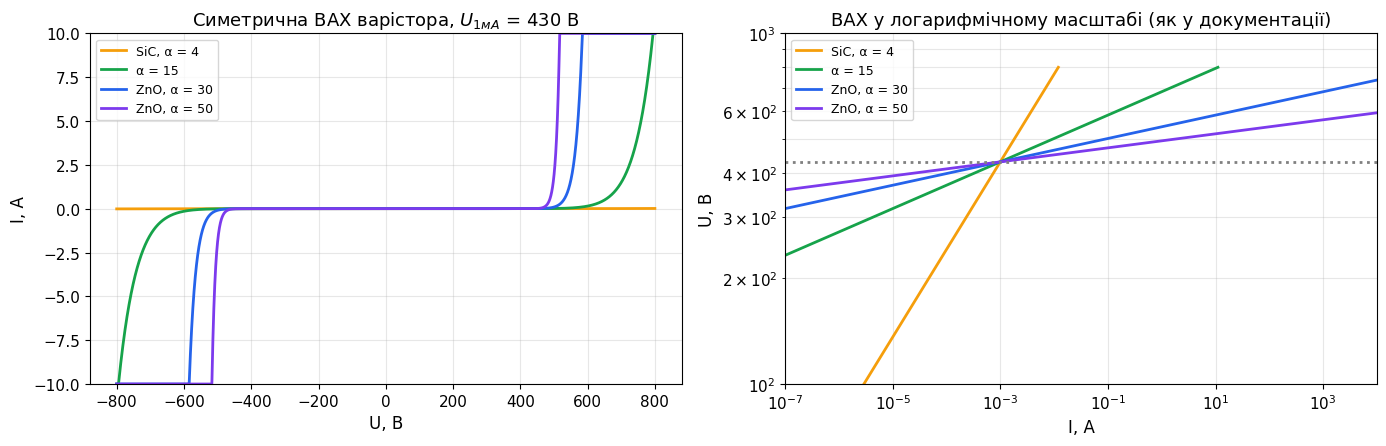

In [7]:
U = np.linspace(-800, 800, 4001)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for alpha, col, lab in [(4, '#f59e0b', 'SiC, α = 4'), (15, '#16a34a', 'α = 15'), (30, '#2563eb', 'ZnO, α = 30'), (50, '#7c3aed', 'ZnO, α = 50')]:
    I = 1e-3*np.sign(U)*(np.abs(U)/430)**alpha
    axes[0].plot(U, np.clip(I, -10, 10), color=col, label=lab)
    Up = np.linspace(50, 800, 500)
    axes[1].loglog(1e-3*(Up/430)**alpha, Up, color=col, label=lab)
axes[0].set_ylim(-10, 10); axes[0].set_xlabel('U, В'); axes[0].set_ylabel('I, А'); axes[0].set_title('Симетрична ВАХ варістора, $U_{1мА}$ = 430 В')
axes[0].legend(fontsize=9)
axes[1].set_xlim(1e-7, 1e4); axes[1].set_ylim(100, 1000); axes[1].axhline(430, color='gray', ls=':')
axes[1].set_xlabel('I, А'); axes[1].set_ylabel('U, В'); axes[1].set_title('ВАХ у логарифмічному масштабі (як у документації)')
axes[1].legend(fontsize=9); axes[1].grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()

### ⚙️ PySpice: захист від імпульсної перенапруги <a class="anchor" id="spice-surge"></a>

Обладнання (активний опір 500 Ом) живиться від мережі 230 В; у момент, коли миттєва напруга мережі максимальна, на неї накладається грозовий імпульс **1,2/50 мкс** амплітудою $U_{імп}$ від генератора з внутрішнім опором 2 Ом (комбінований генератор випробувань за IEC 61000-4-5). Варістор S14K275 описано поведінковим джерелом $I = I_1(|U|/U_{1мА})^\alpha\,\mathrm{sgn}\,U$ з послідовним опором 0,2 Ом (опір зерен ZnO і виводів — обмежує крутизну на великих струмах). Порівняйте напругу на обладнанні з варістором і без нього.

In [8]:
def surge(U_surge_kV=4.0, alpha=30, protected=True):
    c = Circuit('Surge protection')
    c.V('mains', 'm', c.gnd, 325)                                     # миттєве значення мережі в максимумі
    c.ExponentialVoltageSource('surge', 's', 'm', initial_value=0, pulsed_value=U_surge_kV*1e3*1.04,
                               rise_delay_time=5e-6, rise_time_constant=0.4e-6, fall_delay_time=6.2e-6, fall_time_constant=68e-6)
    c.R('gen', 's', 'p', 2.0)                                         # внутрішній опір генератора
    if protected:
        c.R('vs', 'p', 'v', 0.2)
        c.B('var', 'v', c.gnd, i=f'1e-3*pow(abs(v(v))/430,{alpha})*sgn(v(v))')
    c.R('load', 'p', c.gnd, 500)
    an = c.simulator().transient(step_time=10e-9, end_time=150e-6, max_time=50e-9)
    t = np.array(an.time)*1e6; up = np.array(an['p']); us = np.array(an['s'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    axes[0].plot(t, us, color='gray', lw=1, label='напруга генератора (х.х.)')
    axes[0].plot(t, up, color='#dc2626', lw=2, label='напруга на обладнанні')
    axes[0].axhline(325, color='k', ls=':', lw=1); axes[0].set_xlabel('t, мкс'); axes[0].set_ylabel('U, В'); axes[0].legend(fontsize=9)
    axes[0].set_title(f'Імпульс {U_surge_kV} кВ (1,2/50 мкс), ' + ('з варістором' if protected else 'без захисту'))
    if protected:
        iv = 1e-3*(np.abs(np.array(an['v']))/430)**alpha
        axes[1].plot(t, iv, color='#2563eb'); axes[1].set_xlabel('t, мкс'); axes[1].set_ylabel('$I_{вар}$, А')
        W = np.trapezoid(iv*np.array(an['v']), t*1e-6)
        axes[1].set_title(f'Струм варістора; поглинута енергія ≈ {W:.1f} Дж')
        print(f'Максимальна напруга на обладнанні: {up.max():.0f} В (без захисту була б ≈ {(U_surge_kV*1e3)*500/502 + 325:.0f} В);'
              f'  піковий струм варістора {iv.max():.0f} А')
    else:
        axes[1].axis('off')
        print(f'Максимальна напруга на обладнанні: {up.max():.0f} В — ізоляція і напівпровідники вхідних кіл пробиваються')
    plt.tight_layout(); plt.show()

interact(surge,
         U_surge_kV=widgets.SelectionSlider(options=[0.5, 1.0, 2.0, 4.0, 6.0], value=4.0, description='$U_{імп}$, кВ', continuous_update=False),
         alpha=widgets.SelectionSlider(options=[5, 15, 30, 50], value=30, description='α', continuous_update=False),
         protected=widgets.Checkbox(value=True, description='варістор S14K275'));

interactive(children=(SelectionSlider(continuous_update=False, description='$U_{імп}$, кВ', index=3, options=(…

---
### ⚡ Практичне застосування: Вибір варістора для мережевого обладнання

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

1. **Робоча напруга** з запасом на допуск мережі: для 230 В ± 10 % → $U_{RMS}$ ≥ 253 В; стандартний вибір — **275 В** (класифікаційна напруга ≈ 430 В).
2. **Енергія і струм імпульсу**: оцінюють за рівнем перенапруг у місці встановлення (вхід приладу — 1–2 кВ, щиток будинку — 4–6 кВ); більший діаметр диска (7, 10, 14, 20 мм) — більші $I_{max}$ і $W_{max}$.
3. **Напруга обмеження** має бути меншою за електричну міцність захищуваних елементів (вхідних діодів, конденсаторів, ізоляції).
4. Обов'язково **послідовний запобіжник** (варістор при руйнуванні замикається накоротко) і **термозахист** (деградований варістор нагрівається струмом витоку).

</div>

---
### ✅ Питання для самоперевірки: ПЗЗ, терморезистори та варістори

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому ПЗЗ працює в режимі глибокого збіднення і чому заряд у потенціальній ямі не можна зберігати як завгодно довго?</summary>

> **Відповідь:** Напругу на затвор подають швидше, ніж утворюється інверсійний шар, тому під затвором — порожня яма, яку заповнює лише корисний (фото- або введений) заряд. Але теплова генерація пар (темновий струм) поступово заповнює яму, тож час зберігання обмежений — мілісекунди при кімнатній температурі, години при охолодженні.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Як ефективність перенесення впливає на якість зображення ПЗЗ-матриці?</summary>

> **Відповідь:** Після $N$ перенесень у пакеті залишається $\eta^N$ заряду, а решта «тягнеться хвостом» за яскравими деталями. Для матриць з тисячами пікселів у рядку потрібна $\eta \ge 0{,}99999$ — тому застосовують прихований канал і рідко — поверхневий.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому NTC-терморезистор має від'ємний, а позистор — додатний ТКО?</summary>

> **Відповідь:** У NTC-кераміці концентрація носіїв зростає з температурою за законом Арреніуса, опір падає. У позисторі (легований BaTiO₃) вище точки Кюрі зникає сегнетоелектрична поляризація, що компенсувала заряди на межах зерен, бар'єри зростають, і опір збільшується на кілька порядків.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому статична ВАХ NTC-терморезистора має ділянку від'ємного опору?</summary>

> **Відповідь:** Зі зростанням струму терморезистор розігрівається, і його опір зменшується швидше, ніж зростає струм. Після максимуму напруги $U_{max}$ подальше збільшення струму супроводжується зменшенням напруги.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 5.</b> Від чого залежать класифікаційна напруга і допустима енергія варістора?</summary>

> **Відповідь:** Класифікаційна напруга пропорційна кількості меж зерен уздовж струму — тобто товщині диска (≈ 3 В на межу). Енергія і допустимий струм — об'єму і площі диска (більший діаметр — більші $I_{max}$, $W_{max}$).

</details>

---
### 📝 Задачі для самостійного розв'язання: ПЗЗ, терморезистори та варістори


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Трифазна ПЗЗ-лінійка має 2048 пікселів, ефективність перенесення η = 0,99995. Яка частка заряду найвіддаленішого пікселя дійде до виходу?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $N = 3\cdot2048 = 6144$ перенесень; $\eta^N = 0{,}99995^{6144} \approx 0.735$ — втрачається ≈ 26 % заряду.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** NTC-терморезистор: $R_{25}$ = 10 кОм, B = 3950 К. Знайдіть його опір при 0 °C і 100 °C та ТКО при 25 °C.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $R(0) = 10\,e^{3950(1/273{,}15 - 1/298{,}15)} \approx 33{,}6$ кОм; $R(100) \approx 0{,}70$ кОм; $\alpha = -B/T^2 = -3950/298{,}15^2 \approx -4{,}4$ %/°C.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Коефіцієнт розсіювання NTC-термістора δ = 2 мВт/°C, опір при температурі вимірювання 10 кОм. Який максимальний струм вимірювання, щоб похибка саморозігріву не перевищувала 0,05 °C?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $P = I^2R \le \delta\Delta T = 2\cdot10^{-3}\cdot0{,}05 = 10^{-4}$ Вт → $I \le \sqrt{10^{-4}/10^4} = 100$ мкА.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** Варістор має $U_{1мА}$ = 430 В і α = 30. Оцініть напругу на ньому при імпульсному струмі 100 А (без урахування послідовного опору).

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $U = U_{1мА}(I/I_1)^{1/\alpha} = 430\cdot(10^5)^{1/30} = 430\cdot1{,}47 \approx 630$ В.

</details>

---

## 📌 Підсумок лекції 13: ПЗЗ, терморезистори та варістори <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Прилад | Фізична основа | Ключові параметри | Застосування |
|---|---|---|---|
| **ПЗЗ** | МДН-конденсатори в режимі глибокого збіднення, перенесення зарядових пакетів | ефективність перенесення, повна ємність пікселя, темновий струм, шум зчитування | наукові та астрономічні камери, спектрометри, сканери |
| **NTC-терморезистор** | термоактивована провідність оксидної кераміки | $R_{25}$, B, δ, τ | вимірювання і компенсація температури, обмеження пускового струму |
| **PTC-позистор** | бар'єри на межах зерен BaTiO₃ вище точки Кюрі | $R_{25}$, $T_C$, кратність | самовідновлювані запобіжники, саморегульовані нагрівачі |
| **Варістор** | подвійні бар'єри Шотки на межах зерен ZnO | $U_{1мА}$, α, $U_{обм}$, $I_{max}$, $W_{max}$ | захист від імпульсних перенапруг |

**Головні висновки.** (1) ПЗЗ зберігає і переносить інформацію у вигляді зарядових пакетів у потенціальних ямах; якість зображення визначається ефективністю перенесення $\eta^N$. (2) КМОН-сенсори витіснили ПЗЗ з масових камер, але ПЗЗ лишаються еталоном для наукових застосувань. (3) Опір NTC експоненційно спадає з температурою ($\alpha_R = -B/T^2$), позистора — стрибкоподібно зростає біля точки Кюрі. (4) Саморозігрів визначає режим роботи терморезистора: малий струм — вимірювання, великий — обмеження струму, захист. (5) Варістор — мережа мікробар'єрів у ZnO-кераміці з ВАХ $I \propto U^{\alpha}$, що обмежує перенапруги за наносекунди, поглинаючи енергію імпульсу.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 12. Оптоелектронні прилади](Лекція_12_Оптоелектронні_прилади.ipynb)</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*